## Data Sampling In  MNIST

In [244]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import copy

import numpy as np
import scipy.stats as stats

import polars as pl
import plotly.express as px
import plotly.io as pio

from great_tables import GT, html

# show all columns without truncation
pl.Config.set_tbl_cols(-1)

polars.config.Config

In [245]:
# import data
# raw_data = pl.read_csv('/content/sample_data/mnist_train_small.csv')

raw_data = pl.read_csv("/Users/yokefeipang/Library/CloudStorage/GoogleDrive-kennethpang7@gmail.com/Other computers/My Mac/Python Lessons/DUDL_PythonCode/FFN/mnist_train_small.csv")

In [246]:
print(raw_data.shape)

(19999, 785)


## create a function to prepare the dataset with differen specified size


In [247]:
def createDataset(N, doubleTheData=True):
  # separate the data/features and the labels
  # slice the rows accoring to the N
  labels = raw_data[:N, 0]
  features = raw_data[:N, 1:] # this get all the features except the label

  # normalize the data
  scaler = MinMaxScaler()
  scaled_features = scaler.fit_transform(features)

  # make an exact copy of all the slected data if doubleTheData is True
  # this is actually a bad way of oversampling - we want to just oversample (double the Training) set only
  # if doubleTheData:
  #   scaled_features = np.concatenate((scaled_features, scaled_features), axis=0)
  #   labels = np.concatenate((labels, labels), axis=0)

  # convert to tensor data
  dataT = torch.tensor(scaled_features, dtype=torch.float32)
  labelsT = torch.tensor(labels, dtype=torch.long)

  # split the data using scikit learn
  X_train, X_test, y_train, y_test = train_test_split(
        dataT, labelsT, test_size=0.2, random_state=42)

  # make an exact copy of the TRAIN data - not like above since that duplicated dataset will bleed into the dev test
  if doubleTheData:
      X_train = torch.cat((X_train, X_train), axis=0)
      y_train = torch.cat((y_train, y_train), axis=0)

  # convert to torch.dataset
  train_dataset = TensorDataset(X_train, y_train)
  test_dataset = TensorDataset(X_test, y_test)

  # translate into dataloader objects
  batchSize = 20
  train_loader = DataLoader(train_dataset, batch_size=batchSize, shuffle=True, drop_last=True)
  test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

  return train_loader, test_loader

In [248]:
train_loader, test_loader = createDataset(200, doubleTheData=False)

# check the sizes
print('\n**********Check the size************')
print(train_loader.dataset.tensors[0].shape)
print(test_loader.dataset.tensors[0].shape)

# if we multiply the data by two
print('\n**********Double the Data************')
train_loader, test_loader = createDataset(200, doubleTheData=True)
print(train_loader.dataset.tensors[0].shape)
print(test_loader.dataset.tensors[0].shape)




**********Check the size************
torch.Size([160, 784])
torch.Size([40, 784])

**********Double the Data************
torch.Size([320, 784])
torch.Size([40, 784])


## create the model and components

In [249]:
# construct the class for the model
class ANNmodel(nn.Module):
  def __init__(self, nUnits, nLayers):
    super().__init__()

    # create a dictionary to store the layers
    self.layers = nn.ModuleDict()

    # input layers
    self.layers['input'] = nn.Linear(784, nUnits)

    # generate the hidden layers
    for i in range(nLayers):
      self.layers[f'hidden{i}'] = nn.Linear(nUnits, nUnits)

    # output layer
    self.layers['output'] = nn.Linear(nUnits, 10)

  def forward(self, x):
    x = F.relu(self.layers['input'](x))

    # hidden layers
    for i in range(len(self.layers) - 2): # minus the input and output layers
      x = F.relu(self.layers[f'hidden{i}'](x))

    # return output layer
    x = self.layers['output'](x)
    return x

In [250]:
# create the components
def createANNnet(train_loader, test_loader, nUnits, nLayers, learningRate=0.01, epochStep=10, gamma=1/2):
  model = ANNmodel(nUnits, nLayers)
  lossfunc = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=learningRate)

  step_size = len(train_loader) * epochStep
  scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

  return model, lossfunc, optimizer, scheduler

In [251]:
def trainModel(train_loader, test_loader, nUnits, nLayers, numepochs=500, toggleDynamic=True):
    training_progress = pl.DataFrame(
        schema=[
            ('iteration', pl.Int64),
            ('epoch', pl.Int64),
            ('train_loss', pl.Float64),
            ('train_acc', pl.Float64),
            ('test_loss', pl.Float64),
            ('test_acc', pl.Float64),
            ('learning_rate', pl.Float64)
        ]
    )
    iteration = 0

    # create the ANN model
    model, lossfunc, optimizer, scheduler = createANNnet(
        train_loader, test_loader ,nUnits, nLayers, learningRate=0.001, epochStep=10, gamma=1/2,
    )

    # load the test data once
    X_testTL, y_testTL = next(iter(test_loader))

    # early stopping parameters
    patience = 100
    best_loss = float('inf')
    no_improvement_count = 0
    best_model = None

    # training loop
    for epoch in range(numepochs):
        model.train()

        epoch_train_loss = 0
        epoch_train_acc = 0
        num_batches = 0

        # iterate through the training batches
        for X_trainTL, y_trainTL in train_loader:
            yhat_train = model(X_trainTL)
            train_loss = lossfunc(yhat_train.squeeze(), y_trainTL)

            optimizer.zero_grad()
            train_loss.backward()
            optimizer.step()

            # get accuracy
            train_matches = (torch.argmax(yhat_train, axis=1) == y_trainTL).float()
            train_acc = 100 * torch.mean(train_matches)

            epoch_train_loss += train_loss.item()
            epoch_train_acc += train_acc.item()
            num_batches += 1

        # Update learning rate after all batches (once per epoch)
        if toggleDynamic:
            scheduler.step()
            current_lrs = scheduler.get_last_lr()[0]
        else:
            current_lrs = optimizer.param_groups[0]['lr']

        # end of epoch: evaluate test once
        model.eval()
        with torch.no_grad():
            yhat_test = model(X_testTL)
            test_loss = lossfunc(yhat_test.squeeze(), y_testTL)
            # get test acc
            test_matches = (torch.argmax(yhat_test, axis=1) == y_testTL).float()
            test_acc = 100 * torch.mean(test_matches)

        # log single row per epoch
        new_row = pl.DataFrame([{
            'iteration': iteration,
            'epoch': epoch,
            'train_loss': epoch_train_loss / num_batches,
            'train_acc': epoch_train_acc / num_batches,
            'test_loss': test_loss.item(),
            'test_acc': test_acc.item(),
            'learning_rate': current_lrs
        }])

        training_progress = training_progress.vstack(new_row)
        iteration += 1

        # early stopping if model does not improve
        if test_loss < best_loss:
            best_loss = test_loss.item()  # update best loss when model improves
            no_improvement_count = 0  # reset the counter to 0
            best_model = copy.deepcopy(model)  # copy the model and preserve the best weights

        else:
            no_improvement_count += 1
            if no_improvement_count >= patience:
                print(f'Stopping at epoch {epoch + 1} - No improvement for {patience} epochs')
                break

        if epoch % 10 == 0 or epoch == numepochs - 1:
            print(
                f"Epoch {epoch+1}/{numepochs} - "
                f"Training: Loss={epoch_train_loss / num_batches:.4f}, "
                f"Accuracy={epoch_train_acc / num_batches:.2f}% | "
                f"Testing: Loss={test_loss.item():.4f}, "
                f"Accuracy={test_acc.item():.2f}% | "
                f"Learning Rate: {current_lrs:.6f}"
            )

    # Return both training progress and best model
    return training_progress, best_model if best_model is not None else model

In [252]:
# generate a dataset to test if the codes work!!!
# have a test of the model
# define the parameteres
numOfUnit = 64
numOfLayers = 2
train_loader,test_loader = createDataset(500)

training_progress, trained_model = trainModel(train_loader=train_loader, test_loader=test_loader, nUnits=64, nLayers=2, numepochs=500, toggleDynamic=False)


Epoch 1/500 - Training: Loss=2.1482, Accuracy=26.63% | Testing: Loss=1.9337, Accuracy=23.00% | Learning Rate: 0.001000
Epoch 11/500 - Training: Loss=0.0191, Accuracy=99.88% | Testing: Loss=0.4458, Accuracy=84.00% | Learning Rate: 0.001000
Epoch 21/500 - Training: Loss=0.0024, Accuracy=100.00% | Testing: Loss=0.5267, Accuracy=84.00% | Learning Rate: 0.001000
Epoch 31/500 - Training: Loss=0.0009, Accuracy=100.00% | Testing: Loss=0.5345, Accuracy=84.00% | Learning Rate: 0.001000
Epoch 41/500 - Training: Loss=0.0004, Accuracy=100.00% | Testing: Loss=0.5799, Accuracy=85.00% | Learning Rate: 0.001000
Epoch 51/500 - Training: Loss=0.0002, Accuracy=100.00% | Testing: Loss=0.6508, Accuracy=85.00% | Learning Rate: 0.001000
Epoch 61/500 - Training: Loss=0.0001, Accuracy=100.00% | Testing: Loss=0.6860, Accuracy=86.00% | Learning Rate: 0.001000
Epoch 71/500 - Training: Loss=0.0001, Accuracy=100.00% | Testing: Loss=0.7186, Accuracy=86.00% | Learning Rate: 0.001000
Epoch 81/500 - Training: Loss=0.000

## Running the experiment

In [253]:
# this was using claude AI's improvement to my class accuracy (my original code is below)
# list of data sample sizes
samplesizes = np.arange(500, 4001, 500)

# define the hyperparameters
numOfUnit = 64
numOfLayers = 2

all_results = []
class_acc = []

for size in samplesizes:
    print(f'Training with sample size {size}')

    # FIXED: Create the dataset with the current sample size
    train_loader, test_loader = createDataset(size)  # ← Changed from 500 to size

    # train the model
    training_progress, trained_model = trainModel(
        train_loader=train_loader,
        test_loader=test_loader,
        nUnits=numOfUnit,
        nLayers=numOfLayers,
        numepochs=500,
        toggleDynamic=False
    )

    # create a column to annotate the sample size & append to the all_results
    training_progress = training_progress.with_columns(sample_size=pl.lit(size))
    all_results.append(training_progress)

    # compute per class accuracy
    trained_model.eval()
    with torch.no_grad():
        X, y = next(iter(test_loader))

        # FIXED: Get predictions correctly with proper dimension handling
        logits = trained_model(X)
        predictions = torch.argmax(logits, dim=1)  # specify dimension
        correct = (predictions == y)  # Simplified: both are integers

        # IMPROVED: More efficient per-class accuracy calculation
        per_class_acc = {}
        for class_idx in range(10):  # MNIST has 10 classes (0-9)
            class_mask = (y == class_idx)
            if torch.sum(class_mask) > 0:  # Check if class exists in test set
                class_correct = correct[class_mask]
                per_class_acc[f'num_{class_idx}'] = (100 * torch.mean(class_correct.float())).item()
            else:
                per_class_acc[f'num_{class_idx}'] = 0.0

        # overall accuracy
        overall_acc = (100 * torch.mean(correct.float())).item()

        # store the results in class_acc
        class_row = pl.DataFrame([{
            'sample_size': size,
            'overall_acc': overall_acc,  # ← Added overall accuracy
            **per_class_acc  # ← Unpack the per-class accuracies
        }])

        # append the class_result
        class_acc.append(class_row)

# combine the results
experiment_results = pl.concat(all_results)
class_results = pl.concat(class_acc)

print(f"Experiment complete! Trained on sample sizes: {samplesizes}")
print(f"Final results shape: {experiment_results.shape}")
print(f"Class accuracy results shape: {class_results.shape}")

Training with sample size 500
Epoch 1/500 - Training: Loss=2.1319, Accuracy=28.63% | Testing: Loss=1.8669, Accuracy=52.00% | Learning Rate: 0.001000
Epoch 11/500 - Training: Loss=0.0233, Accuracy=100.00% | Testing: Loss=0.4015, Accuracy=86.00% | Learning Rate: 0.001000
Epoch 21/500 - Training: Loss=0.0022, Accuracy=100.00% | Testing: Loss=0.4871, Accuracy=85.00% | Learning Rate: 0.001000
Epoch 31/500 - Training: Loss=0.0008, Accuracy=100.00% | Testing: Loss=0.5418, Accuracy=85.00% | Learning Rate: 0.001000
Epoch 41/500 - Training: Loss=0.0004, Accuracy=100.00% | Testing: Loss=0.5803, Accuracy=85.00% | Learning Rate: 0.001000
Epoch 51/500 - Training: Loss=0.0002, Accuracy=100.00% | Testing: Loss=0.6090, Accuracy=85.00% | Learning Rate: 0.001000
Epoch 61/500 - Training: Loss=0.0001, Accuracy=100.00% | Testing: Loss=0.6431, Accuracy=84.00% | Learning Rate: 0.001000
Epoch 71/500 - Training: Loss=0.0001, Accuracy=100.00% | Testing: Loss=0.6642, Accuracy=84.00% | Learning Rate: 0.001000
Epoc

In [254]:
# list of data sample sizes
samplesizes = np.arange(500, 4001, 500)

# define the hyperparameters
numOfUnit = 64
numOfLayers = 2

all_results = []
class_acc = []

for size in samplesizes:
    print(f'Training with sample size {size}')

    # Create the dataset with the current sample size
    train_loader, test_loader = createDataset(size)

    # train the model
    training_progress, trained_model = trainModel(
        train_loader=train_loader,
        test_loader=test_loader,
        nUnits=numOfUnit,
        nLayers=numOfLayers,
        numepochs=500,
        toggleDynamic=False
    )

    # create a column to annotate the sample size & append to the all_results
    training_progress = training_progress.with_columns(sample_size=pl.lit(size))
    all_results.append(training_progress)

    # compute per class accuracy
    trained_model.eval()
    with torch.no_grad():
        X, y = next(iter(test_loader))

        # Get predictions
        logits = trained_model(X)
        predictions = torch.argmax(logits, dim=1)  # specify dimension
        correct = (predictions == y)  # Simplified: both are integers

        # per class accuracy
        num_0 = 100 * torch.mean(correct[y == 0].float()) if torch.sum(y == 0) > 0 else 0
        num_1 = 100 * torch.mean(correct[y == 1].float()) if torch.sum(y == 1) > 0 else 0
        num_2 = 100 * torch.mean(correct[y == 2].float()) if torch.sum(y == 2) > 0 else 0
        num_3 = 100 * torch.mean(correct[y == 3].float()) if torch.sum(y == 3) > 0 else 0
        num_4 = 100 * torch.mean(correct[y == 4].float()) if torch.sum(y == 4) > 0 else 0
        num_5 = 100 * torch.mean(correct[y == 5].float()) if torch.sum(y == 5) > 0 else 0
        num_6 = 100 * torch.mean(correct[y == 6].float()) if torch.sum(y == 6) > 0 else 0
        num_7 = 100 * torch.mean(correct[y == 7].float()) if torch.sum(y == 7) > 0 else 0
        num_8 = 100 * torch.mean(correct[y == 8].float()) if torch.sum(y == 8) > 0 else 0
        num_9 = 100 * torch.mean(correct[y == 9].float()) if torch.sum(y == 9) > 0 else 0

        # overall accuracy
        overall_acc = 100 * torch.mean(correct.float())

        # store the results in class_acc
        class_row = pl.DataFrame([{
            'sample_size': size,
            'num_0': num_0.item(),
            'num_1': num_1.item(),
            'num_2': num_2.item(),
            'num_3': num_3.item(),
            'num_4': num_4.item(),
            'num_5': num_5.item(),
            'num_6': num_6.item(),
            'num_7': num_7.item(),
            'num_8': num_8.item(),
            'num_9': num_9.item(),
        }])

        # append the class_result
        class_acc.append(class_row)

# combine the results
experiment_results = pl.concat(all_results)
class_results = pl.concat(class_acc)


Training with sample size 500
Epoch 1/500 - Training: Loss=2.1386, Accuracy=27.88% | Testing: Loss=1.8968, Accuracy=37.00% | Learning Rate: 0.001000
Epoch 11/500 - Training: Loss=0.0315, Accuracy=99.88% | Testing: Loss=0.7724, Accuracy=78.00% | Learning Rate: 0.001000
Epoch 21/500 - Training: Loss=0.0035, Accuracy=100.00% | Testing: Loss=0.9646, Accuracy=77.00% | Learning Rate: 0.001000
Epoch 31/500 - Training: Loss=0.0013, Accuracy=100.00% | Testing: Loss=1.0415, Accuracy=76.00% | Learning Rate: 0.001000
Epoch 41/500 - Training: Loss=0.0006, Accuracy=100.00% | Testing: Loss=1.1297, Accuracy=77.00% | Learning Rate: 0.001000
Epoch 51/500 - Training: Loss=0.0004, Accuracy=100.00% | Testing: Loss=1.1959, Accuracy=77.00% | Learning Rate: 0.001000
Epoch 61/500 - Training: Loss=0.0002, Accuracy=100.00% | Testing: Loss=1.2477, Accuracy=77.00% | Learning Rate: 0.001000
Epoch 71/500 - Training: Loss=0.0002, Accuracy=100.00% | Testing: Loss=1.2942, Accuracy=76.00% | Learning Rate: 0.001000
Epoch

In [255]:
# inspect the experiment results
grouped_results = (
    experiment_results
    .group_by('sample_size', 'epoch')
    .agg(
        pl.selectors.numeric().mean().name.prefix('mean_')
    ).sort('sample_size', 'epoch', descending=False)
)

print(grouped_results.head())

shape: (5, 8)
┌────────────┬───────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┐
│ sample_siz ┆ epoch ┆ mean_itera ┆ mean_train ┆ mean_train ┆ mean_test_ ┆ mean_test_ ┆ mean_learn │
│ e          ┆ ---   ┆ tion       ┆ _loss      ┆ _acc       ┆ loss       ┆ acc        ┆ ing_rate   │
│ ---        ┆ i64   ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│ i32        ┆       ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64        │
╞════════════╪═══════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╡
│ 500        ┆ 0     ┆ 0.0        ┆ 2.138629   ┆ 27.875     ┆ 1.896775   ┆ 37.0       ┆ 0.001      │
│ 500        ┆ 1     ┆ 1.0        ┆ 1.362927   ┆ 52.25      ┆ 1.218349   ┆ 43.0       ┆ 0.001      │
│ 500        ┆ 2     ┆ 2.0        ┆ 0.823799   ┆ 74.25      ┆ 0.78661    ┆ 74.0       ┆ 0.001      │
│ 500        ┆ 3     ┆ 3.0        ┆ 0.493299   ┆ 87.875     ┆ 0.617749   ┆ 75

## inspect the overall accuracy

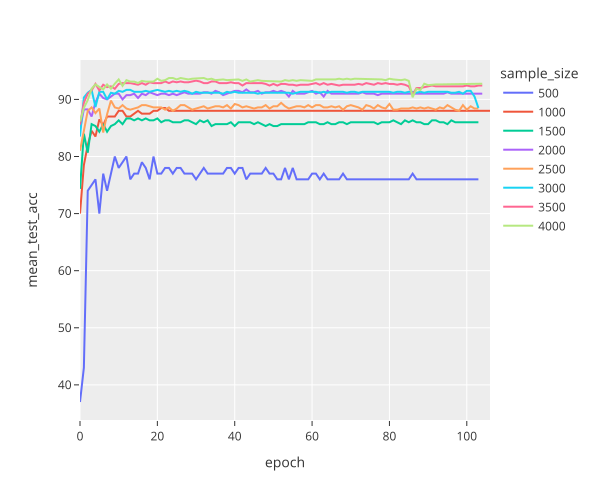

In [256]:
fig = px.line(
    grouped_results,
    x='epoch',
    y='mean_test_acc',
    color='sample_size'
)

fig.update_layout(template='ggplot2', width=600)

fig.show(renderer='svg')

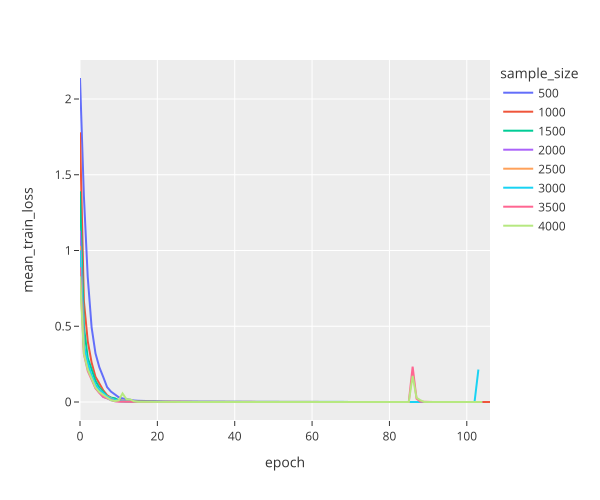

In [257]:
fig = px.line(
    grouped_results,
    x='epoch',
    y='mean_train_loss',
    color='sample_size'
)

fig.update_layout(template='ggplot2', width=600)

fig.show(renderer='svg')

## Inspect the per-class-accuracy & create a nice table

In [258]:
# round the percentage & rename the column name
map = {
    'num_0' : '0',
    'num_1' : '1',
    'num_2' : '2',
    'num_3' : '3',
    'num_4' : '4',
    'num_5' : '5',
    'num_6' : '6',
    'num_7' : '7',
    'num_8' : '8',
    'num_9' : '9',
}

class_results = (
    class_results
    .with_columns(pl.selectors.float().round(1))
    .rename(map)
)

In [282]:
# I remove those table because it color grading doesnt match the message of the table
(
    GT(class_results)
    .data_color(
        palette=['white', 'darkgreen',],
        columns=class_results.select(pl.selectors.float()).columns,
        domain=[60,100]
    )
    .tab_stub(rowname_col='sample_size')
    .tab_stubhead(label='Sample Size')
    .tab_header(
        title='Per Class Accuracy for Different Sample Size (%)',
        subtitle='MNIST has 10 classes (0-9)'
    )
    .opt_stylize(style=2, color="gray")
)

GT(_tbl_data=shape: (8, 11)
┌─────────────┬──────┬───────┬──────┬──────┬──────┬──────┬───────┬──────┬──────┬──────┐
│ sample_size ┆ 0    ┆ 1     ┆ 2    ┆ 3    ┆ 4    ┆ 5    ┆ 6     ┆ 7    ┆ 8    ┆ 9    │
│ ---         ┆ ---  ┆ ---   ┆ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---   ┆ ---  ┆ ---  ┆ ---  │
│ i64         ┆ f64  ┆ f64   ┆ f64  ┆ f64  ┆ f64  ┆ f64  ┆ f64   ┆ f64  ┆ f64  ┆ f64  │
╞═════════════╪══════╪═══════╪══════╪══════╪══════╪══════╪═══════╪══════╪══════╪══════╡
│ 500         ┆ 87.5 ┆ 92.9  ┆ 60.0 ┆ 62.5 ┆ 40.0 ┆ 87.5 ┆ 88.9  ┆ 92.3 ┆ 75.0 ┆ 50.0 │
│ 1000        ┆ 78.6 ┆ 100.0 ┆ 90.3 ┆ 88.2 ┆ 85.7 ┆ 61.1 ┆ 94.1  ┆ 85.0 ┆ 88.5 ┆ 81.5 │
│ 1500        ┆ 96.4 ┆ 97.2  ┆ 85.3 ┆ 95.8 ┆ 77.8 ┆ 59.4 ┆ 95.8  ┆ 84.4 ┆ 80.0 ┆ 87.9 │
│ 2000        ┆ 94.7 ┆ 95.5  ┆ 86.7 ┆ 94.1 ┆ 92.7 ┆ 69.2 ┆ 100.0 ┆ 87.5 ┆ 89.2 ┆ 88.4 │
│ 2500        ┆ 89.7 ┆ 92.5  ┆ 90.9 ┆ 82.6 ┆ 93.1 ┆ 80.4 ┆ 95.8  ┆ 92.9 ┆ 85.5 ┆ 83.0 │
│ 3000        ┆ 98.5 ┆ 98.6  ┆ 83.6 ┆ 82.1 ┆ 88.9 ┆ 85.4 ┆ 98.1  ┆ 95.5 ┆ 89.8 ┆ 92.4 │
│ 3500        ┆ 95.7 ┆ 96.0  ┆ 93.1 ┆ 84.8 ┆ 96.8 ┆ 88.5 ┆ 100.0 ┆ 91.3 ┆ 86.7 ┆ 93.2 │
│ 4000        ┆ 98.7 ┆ 98.8  ┆ 87.8 ┆ 96.9 ┆ 90.5 ┆ 91.6 ┆ 97.6  ┆ 89.0 ┆ 82.1 ┆ 93.8 │
└─────────────┴──────┴───────┴──────┴──────┴──────┴──────┴───────┴──────┴──────┴──────┘, _body=<great_tables._gt_data.Body object at 0x35ee324e0>, _boxhead=Boxhead([ColInfo(var='sample_size', type=<ColInfoTypeEnum.stub: 2>, column_label='sample_size', column_align='right', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='0', column_align='right', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='1', column_align='right', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='2', column_align='right', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='3', column_align='right', column_width=None), ColInfo(var='4', type=<ColInfoTypeEnum.default: 1>, column_label='4', column_align='right', column_width=None), ColInfo(var='5', type=<ColInfoTypeEnum.default: 1>, column_label='5', column_align='right', column_width=None), ColInfo(var='6', type=<ColInfoTypeEnum.default: 1>, column_label='6', column_align='right', column_width=None), ColInfo(var='7', type=<ColInfoTypeEnum.default: 1>, column_label='7', column_align='right', column_width=None), ColInfo(var='8', type=<ColInfoTypeEnum.default: 1>, column_label='8', column_align='right', column_width=None), ColInfo(var='9', type=<ColInfoTypeEnum.default: 1>, column_label='9', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x35ee2fb90>, _spanners=Spanners([]), _heading=Heading(title='Per Class Accuracy for Different Sample Size (%)', subtitle='MNIST has 10 classes (0-9)', preheader=None), _stubhead='Sample Size', _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='0', rows=[0], mask=None), grpname=None, colname='0', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#509450')]), StyleInfo(locname=LocBody(columns='0', rows=[1], mask=None), grpname=None, colname='0', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#88b788')]), StyleInfo(locname=LocBody(columns='0', rows=[2], mask=None), grpname=None, colname='0', rownum=2, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#177217')]), StyleInfo(locname=LocBody(columns='0', rows=[3], mask=None), grpname=None, colname='0', rownum=3, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, 

In [260]:
# playing around to transpose the plot
transpose_data = class_results.transpose(include_header=True, column_names=['500', '1000', '1500', '2000', '2500', '3000', '4500', '4000']).slice(1,10).rename({'column' : 'index'})

In [283]:
gt_table = (
    GT(transpose_data)
    .data_color(
        palette=['white', 'orange',],
        columns=transpose_data.select(pl.selectors.float()).columns,
        domain=[60, 100]
    )
    .tab_header(
        title='Per Class Accuracy for Different Sample Size (%)',
    )
    .tab_spanner(label='MNIST', columns='index')
    .tab_spanner(label='Different Sample Size', columns=transpose_data.select(pl.selectors.exclude('index')).columns)
    .opt_stylize(style=1, color='gray', add_row_striping=False)
    .opt_table_outline()
    .opt_all_caps()
)

gt_table

GT(_tbl_data=shape: (10, 9)
┌───────┬──────┬───────┬──────┬───────┬──────┬──────┬───────┬──────┐
│ index ┆ 500  ┆ 1000  ┆ 1500 ┆ 2000  ┆ 2500 ┆ 3000 ┆ 4500  ┆ 4000 │
│ ---   ┆ ---  ┆ ---   ┆ ---  ┆ ---   ┆ ---  ┆ ---  ┆ ---   ┆ ---  │
│ str   ┆ f64  ┆ f64   ┆ f64  ┆ f64   ┆ f64  ┆ f64  ┆ f64   ┆ f64  │
╞═══════╪══════╪═══════╪══════╪═══════╪══════╪══════╪═══════╪══════╡
│ 0     ┆ 87.5 ┆ 78.6  ┆ 96.4 ┆ 94.7  ┆ 89.7 ┆ 98.5 ┆ 95.7  ┆ 98.7 │
│ 1     ┆ 92.9 ┆ 100.0 ┆ 97.2 ┆ 95.5  ┆ 92.5 ┆ 98.6 ┆ 96.0  ┆ 98.8 │
│ 2     ┆ 60.0 ┆ 90.3  ┆ 85.3 ┆ 86.7  ┆ 90.9 ┆ 83.6 ┆ 93.1  ┆ 87.8 │
│ 3     ┆ 62.5 ┆ 88.2  ┆ 95.8 ┆ 94.1  ┆ 82.6 ┆ 82.1 ┆ 84.8  ┆ 96.9 │
│ 4     ┆ 40.0 ┆ 85.7  ┆ 77.8 ┆ 92.7  ┆ 93.1 ┆ 88.9 ┆ 96.8  ┆ 90.5 │
│ 5     ┆ 87.5 ┆ 61.1  ┆ 59.4 ┆ 69.2  ┆ 80.4 ┆ 85.4 ┆ 88.5  ┆ 91.6 │
│ 6     ┆ 88.9 ┆ 94.1  ┆ 95.8 ┆ 100.0 ┆ 95.8 ┆ 98.1 ┆ 100.0 ┆ 97.6 │
│ 7     ┆ 92.3 ┆ 85.0  ┆ 84.4 ┆ 87.5  ┆ 92.9 ┆ 95.5 ┆ 91.3  ┆ 89.0 │
│ 8     ┆ 75.0 ┆ 88.5  ┆ 80.0 ┆ 89.2  ┆ 85.5 ┆ 89.8 ┆ 86.7  ┆ 82.1 │
│ 9     ┆ 50.0 ┆ 81.5  ┆ 87.9 ┆ 88.4  ┆ 83.0 ┆ 92.4 ┆ 93.2  ┆ 93.8 │
└───────┴──────┴───────┴──────┴───────┴──────┴──────┴───────┴──────┘, _body=<great_tables._gt_data.Body object at 0x35ecfa270>, _boxhead=Boxhead([ColInfo(var='index', type=<ColInfoTypeEnum.default: 1>, column_label='index', column_align='left', column_width=None), ColInfo(var='500', type=<ColInfoTypeEnum.default: 1>, column_label='500', column_align='right', column_width=None), ColInfo(var='1000', type=<ColInfoTypeEnum.default: 1>, column_label='1000', column_align='right', column_width=None), ColInfo(var='1500', type=<ColInfoTypeEnum.default: 1>, column_label='1500', column_align='right', column_width=None), ColInfo(var='2000', type=<ColInfoTypeEnum.default: 1>, column_label='2000', column_align='right', column_width=None), ColInfo(var='2500', type=<ColInfoTypeEnum.default: 1>, column_label='2500', column_align='right', column_width=None), ColInfo(var='3000', type=<ColInfoTypeEnum.default: 1>, column_label='3000', column_align='right', column_width=None), ColInfo(var='4500', type=<ColInfoTypeEnum.default: 1>, column_label='4500', column_align='right', column_width=None), ColInfo(var='4000', type=<ColInfoTypeEnum.default: 1>, column_label='4000', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x35eccc350>, _spanners=Spanners([SpannerInfo(spanner_id='MNIST', spanner_level=0, spanner_label='MNIST', spanner_units=None, spanner_pattern=None, vars=['index'], built=None), SpannerInfo(spanner_id='Different Sample Size', spanner_level=0, spanner_label='Different Sample Size', spanner_units=None, spanner_pattern=None, vars=['500', '1000', '1500', '2000', '2500', '3000', '4500', '4000'], built=None)]), _heading=Heading(title='Per Class Accuracy for Different Sample Size (%)', subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='500', rows=[0], mask=None), grpname=None, colname='500', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#ffc150')]), StyleInfo(locname=LocBody(columns='500', rows=[1], mask=None), grpname=None, colname='500', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#ffb52d')]), StyleInfo(locname=LocBody(columns='500', rows=[2], mask=None), grpname=None, colname='500', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#ffffff')]), StyleInfo(locname=LocBody(columns='500', rows=[3], mask=None), grpname=None, colname='500', rownum=3, colnum=None, styles=[CellStyleText(co

* larger sample size has better per class accuracy